# Week 1-05 · Weekly Mean Reversion Strategy

This notebook implements a **weekly mean reversion strategy** across the full tradable universe available in `data/egx`.

Strategy rules:
- Use every asset available in the repository's `data/egx` folder.
- Compute each asset's percentage price change over the previous trading week.
- If an asset fell **at least 1.5%** over the previous week, buy **EGP 5** worth.
- If an asset rose **at least 10%** over the previous week, sell **EGP 10** worth.
- Apply the rules at the end of each calendar week, using only information available at that time.
- Never sell more shares than you own.
- Never allow the cash balance to go negative.
- If there is not enough cash for a full EGP 5 purchase, skip that purchase.

This notebook follows the repository's existing style: `DataFeed`, `close` prices, daily value tracking, and simple matplotlib charts.

In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tradinglab.data_feed import DataFeed, load_egx30_returns
from tradinglab import metrics

# Load every tradable stock available in data/egx.
feed = DataFeed.from_dir('data/egx')
prices = feed.close
symbols = feed.symbols
n_assets = feed.n_assets
n_days = feed.n_days

print('Tradable universe size:', n_assets)
print('Symbols:', symbols)
print('Date range:', feed.dates[0].strftime('%Y-%m-%d'), 'to', feed.dates[-1].strftime('%Y-%m-%d'))
print('Trading days in aligned universe:', n_days)


Tradable universe size: 34
Symbols: ['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']
Date range: 2021-10-20 to 2026-07-30
Trading days in aligned universe: 1159


## Weekly signal construction and data assumptions

The repository's `DataFeed` already aligns all symbols on a common set of dates. That means:
- Only dates where every asset has a valid `close` price are used.
- We avoid missing data during the backtest by trading only on the shared calendar.
- If an asset listed later than the universe start, earlier dates are excluded from the dataset.

We use calendar weeks ending on the last trading day of each week. The first full week has no prior weekly signal, so it is held in cash until the second week completes.

In [2]:
dates = feed.dates
week_codes = pd.Series(dates).dt.to_period('W-FRI')
week_end_mask = week_codes != week_codes.shift(-1)
week_end_indices = np.flatnonzero(week_end_mask)
week_end_dates = dates[week_end_indices]

print('Number of calendar weeks in data:', len(week_end_indices))
print('First week end:', week_end_dates[0].strftime('%Y-%m-%d'))
print('Second week end (first decision date):', week_end_dates[1].strftime('%Y-%m-%d'))

weekly_close = prices[week_end_indices]
weekly_change = weekly_close[1:] / weekly_close[:-1] - 1.0

# Decision days are the end-of-week dates after the first week.
decision_indices = week_end_indices[1:]

print('Weekly decision dates sample:')
for d in week_end_dates[1:6]:
    print('-', d.strftime('%Y-%m-%d'))


Number of calendar weeks in data: 247
First week end: 2021-10-20
Second week end (first decision date): 2021-10-28
Weekly decision dates sample:
- 2021-10-28
- 2021-11-04
- 2021-11-11
- 2021-11-18
- 2021-11-25


## Strategy execution and transaction bookkeeping

We execute trades at the weekly close price on the decision day, using only the prior week's observed price movement.

The first week is held in cash because no prior weekly signal exists yet. This avoids look-ahead bias.

In [3]:
START_CASH = 1000.0  # Assumption: use the same starting capital as the repository's weekly examples.

current_cash = START_CASH
current_shares = np.zeros(n_assets, dtype=float)

transaction_records = []

daily_cash = np.zeros(n_days, dtype=float)
daily_holdings_value = np.zeros(n_days, dtype=float)
daily_total_value = np.zeros(n_days, dtype=float)

decision_map = {idx: i for i, idx in enumerate(decision_indices)}

for t in range(n_days):
    if t in decision_map:
        change = weekly_change[decision_map[t]]
        today_prices = prices[t]

        # Sell first: realize any profit-taking signals and free cash for later buys.
        for asset_idx, pct in enumerate(change):
            if pct >= 0.10:
                price = today_prices[asset_idx]
                available_shares = current_shares[asset_idx]
                if available_shares <= 0:
                    continue

                target_value = 10.0
                sell_value = min(target_value, available_shares * price)
                shares_sold = sell_value / price
                current_shares[asset_idx] -= shares_sold
                current_cash += sell_value

                transaction_records.append({
                    'date': dates[t].strftime('%Y-%m-%d'),
                    'asset': symbols[asset_idx],
                    'action': 'SELL',
                    'price': float(price),
                    'amount_egp': float(sell_value),
                    'shares': float(shares_sold),
                    'cash_after': float(current_cash),
                    'position_after': float(current_shares[asset_idx]),
                    'signal': f'weekly change {pct:.2%} >= 10%'
                })

        # Buy next: purchase assets that fell enough last week, if we have enough cash.
        for asset_idx, pct in enumerate(change):
            if pct <= -0.015 and current_cash >= 5.0:
                price = today_prices[asset_idx]
                if price <= 0:
                    continue

                shares_bought = 5.0 / price
                current_shares[asset_idx] += shares_bought
                current_cash -= 5.0

                transaction_records.append({
                    'date': dates[t].strftime('%Y-%m-%d'),
                    'asset': symbols[asset_idx],
                    'action': 'BUY',
                    'price': float(price),
                    'amount_egp': 5.0,
                    'shares': float(shares_bought),
                    'cash_after': float(current_cash),
                    'position_after': float(current_shares[asset_idx]),
                    'signal': f'weekly change {pct:.2%} <= -1.5%'
                })

    today_prices = prices[t]
    holdings_value = float(np.dot(current_shares, today_prices))
    daily_cash[t] = current_cash
    daily_holdings_value[t] = holdings_value
    daily_total_value[t] = current_cash + holdings_value

assert current_cash >= 0.0, 'Cash ended negative, which should not happen.'
assert np.all(current_shares >= -1e-9), 'Negative share holdings detected.'

transactions = pd.DataFrame(transaction_records)
print('Total transactions recorded:', len(transactions))


Total transactions recorded: 1600


## Portfolio performance and risk metrics

We calculate the portfolio's daily value, total return, drawdown, and trading statistics from the transaction history.

In [4]:
portfolio_returns = np.zeros(n_days, dtype=float)
portfolio_returns[1:] = daily_total_value[1:] / daily_total_value[:-1] - 1.0

cumulative_curve = daily_total_value / START_CASH
peak_curve = np.maximum.accumulate(cumulative_curve)
drawdown_pct = (peak_curve - cumulative_curve) / peak_curve
max_drawdown_pct = float(np.max(drawdown_pct))
max_drawdown_egp = float(np.max((peak_curve - cumulative_curve) * START_CASH))

final_value = float(daily_total_value[-1])
profit_loss = float(final_value - START_CASH)
total_return_pct = metrics.total_return(portfolio_returns[1:])

buy_count = int((transactions['action'] == 'BUY').sum())
sell_count = int((transactions['action'] == 'SELL').sum())
total_transactions = len(transactions)

remaining_cash = float(current_cash)
final_holdings = pd.DataFrame({
    'symbol': symbols,
    'shares': current_shares,
    'last_price': prices[-1],
})
final_holdings['market_value'] = final_holdings['shares'] * final_holdings['last_price']
final_holdings = final_holdings.loc[final_holdings['shares'] > 0].sort_values('market_value', ascending=False)

print('Final portfolio value (EGP):', f'{final_value:,.2f}')
print('Profit / Loss (EGP):', f'{profit_loss:,.2f}')
print('Total return:', f'{total_return_pct:.2%}')
print('Max drawdown (EGP):', f'{max_drawdown_egp:,.2f}')
print('Max drawdown (%):', f'{max_drawdown_pct:.2%}')
print('Buy operations:', buy_count)
print('Sell operations:', sell_count)
print('Total transactions:', total_transactions)
print('Remaining cash (EGP):', f'{remaining_cash:,.2f}')
print('Final holdings count:', len(final_holdings))


Final portfolio value (EGP): 5,921.88
Profit / Loss (EGP): 4,921.88
Total return: 492.19%
Max drawdown (EGP): 886.38
Max drawdown (%): 27.71%
Buy operations: 1122
Sell operations: 478
Total transactions: 1600
Remaining cash (EGP): 0.40
Final holdings count: 29


## Benchmark comparison

We compare the strategy to the repository's available benchmarks:
- equal-weight buy-and-hold across the full universe
- the real EGX30 index, if available in `data/egx30.csv`

In [5]:
equal_weight_returns = feed.returns.mean(axis=1)
equal_weight_curve = np.cumprod(1 + equal_weight_returns) * START_CASH

bench_metrics = {
    'equal_weight_final': float(equal_weight_curve[-1]),
    'equal_weight_return': float(metrics.total_return(equal_weight_returns[1:])),
}

egx30_returns = load_egx30_returns('data/egx30.csv', feed.dates)
if egx30_returns is not None:
    egx30_curve = np.cumprod(1 + egx30_returns) * START_CASH
    bench_metrics['egx30_final'] = float(egx30_curve[-1])
    bench_metrics['egx30_return'] = float(metrics.total_return(egx30_returns[1:]))
else:
    egx30_curve = None

print('Equal-weight benchmark final value:', f"{bench_metrics['equal_weight_final']:,.2f}")
print('Equal-weight benchmark return:', f"{bench_metrics['equal_weight_return']:.2%}")
if egx30_returns is not None:
    print('EGX30 benchmark final value:', f"{bench_metrics['egx30_final']:,.2f}")
    print('EGX30 benchmark return:', f"{bench_metrics['egx30_return']:.2%}")
else:
    print('EGX30 benchmark unavailable for this date range.')


Equal-weight benchmark final value: 5,882.67
Equal-weight benchmark return: 488.27%
EGX30 benchmark final value: 4,844.73
EGX30 benchmark return: 384.47%


## Results charts

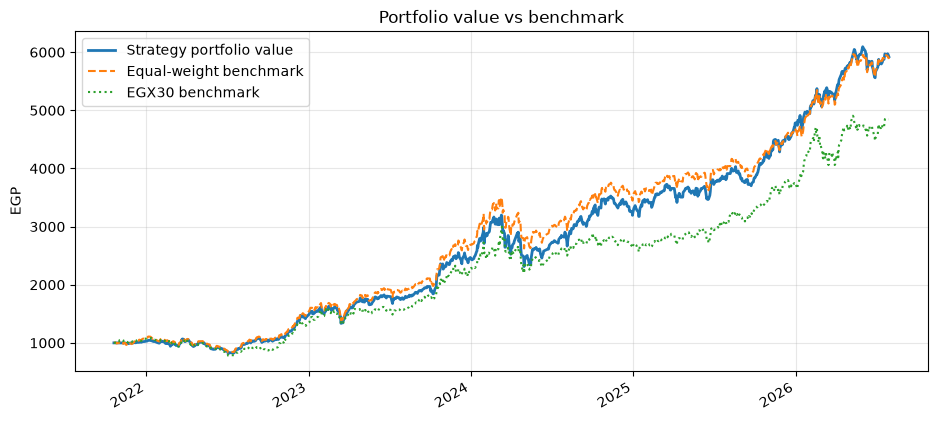

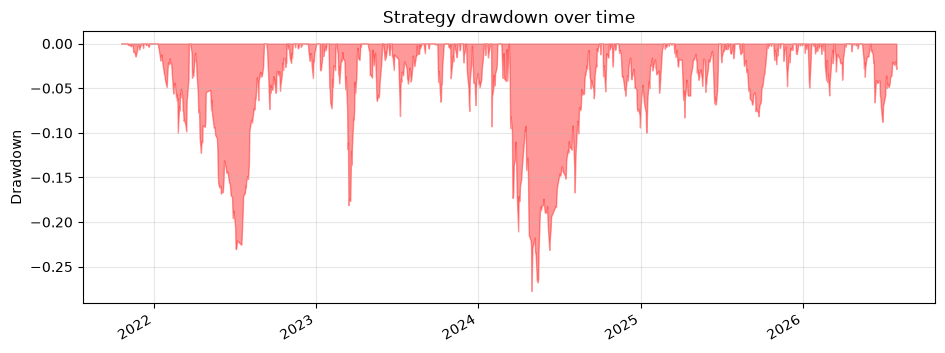

In [6]:
plt.figure(figsize=(11, 5))
plt.plot(dates, daily_total_value, label='Strategy portfolio value', linewidth=2)
plt.plot(dates, equal_weight_curve, label='Equal-weight benchmark', linestyle='--')
if egx30_returns is not None:
    plt.plot(dates, egx30_curve, label='EGX30 benchmark', linestyle=':')
plt.title('Portfolio value vs benchmark')
plt.ylabel('EGP')
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()

plt.figure(figsize=(11, 4))
plt.fill_between(dates, -drawdown_pct, 0, color='red', alpha=0.4)
plt.title('Strategy drawdown over time')
plt.ylabel('Drawdown')
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()


## Price chart with representative buy and sell markers

Because the full universe has many assets, we show the top three most traded symbols and their price paths with weekly buy / sell markers.

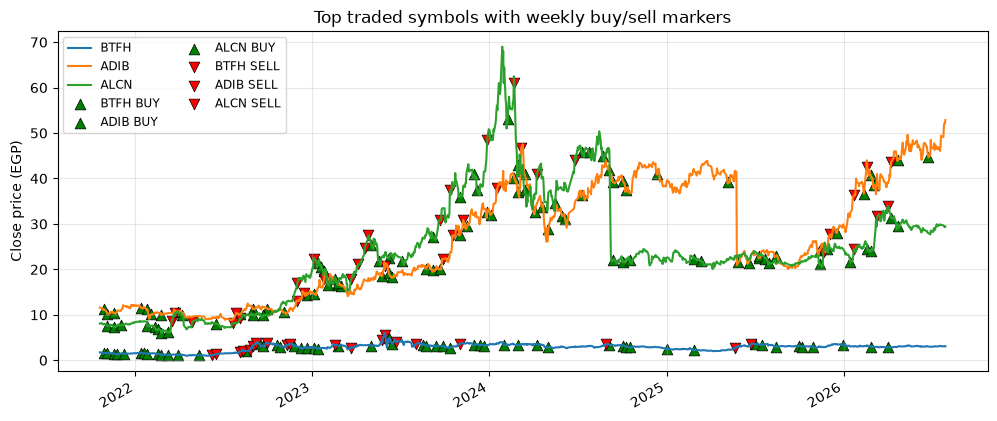

In [7]:
if len(transactions) > 0:
    top_symbols = transactions['asset'].value_counts().head(3).index.tolist()
else:
    top_symbols = symbols[:3]

fig, ax = plt.subplots(figsize=(12, 5))
for sym in top_symbols:
    sym_idx = symbols.index(sym)
    ax.plot(dates, prices[:, sym_idx], label=sym)

for action, marker, color in [('BUY', '^', 'green'), ('SELL', 'v', 'red')]:
    subset = transactions[transactions['action'] == action]
    for sym in top_symbols:
        sym_idx = symbols.index(sym)
        symbol_transactions = subset[subset['asset'] == sym]
        if symbol_transactions.empty:
            continue
        ax.scatter(
            pd.to_datetime(symbol_transactions['date']),
            symbol_transactions['price'],
            marker=marker,
            color=color,
            s=60,
            label=f'{sym} {action}',
            edgecolors='black',
            linewidths=0.5,
        )

ax.set_title('Top traded symbols with weekly buy/sell markers')
ax.set_ylabel('Close price (EGP)')
ax.legend(loc='upper left', fontsize='small', ncols=2)
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.show()


## Transaction log sample

In [8]:
if len(transactions) > 0:
    display(transactions.head(20))
else:
    print('No transactions were generated by this strategy.')


,date,asset,action,price,amount_egp,shares,cash_after,position_after,signal
0,2021-10-28,ADIB,BUY,11.179348,5.000000,0.447253,995.000000,0.447253,weekly change -3.67% <= -1.5%
1,2021-10-28,BTFH,BUY,1.579000,5.000000,3.166561,990.000000,3.166561,weekly change -8.68% <= -1.5%
2,2021-10-28,EAST,BUY,11.600000,5.000000,0.431034,985.000000,0.431034,weekly change -2.60% <= -1.5%
3,2021-10-28,EGAL,BUY,26.059999,5.000000,0.191865,980.000000,0.191865,weekly change -11.06% <= -1.5%
4,2021-10-28,FWRY,BUY,8.130947,5.000000,0.614935,975.000000,0.614935,weekly change -6.00% <= -1.5%
5,2021-10-28,HELI,BUY,4.450000,5.000000,1.123596,970.000000,1.123596,weekly change -4.09% <= -1.5%
6,2021-10-28,ORWE,BUY,8.240000,5.000000,0.606796,965.000000,0.606796,weekly change -1.90% <= -1.5%
7,2021-10-28,PHDC,BUY,1.920000,5.000000,2.604167,960.000000,2.604167,weekly change -2.24% <= -1.5%
8,2021-10-28,RAYA,BUY,2.420000,5.000000,2.066116,955.000000,2.066116,weekly change -7.63% <= -1.5%
9,2021-10-28,SUGR,BUY,15.190000,5.000000,0.329164,950.000000,0.329164,weekly change -3.86% <= -1.5%


## Final summary

This weekly mean reversion strategy used a small fixed cash bet per signal and applied the same rules to every tradable stock in the repository.

Key points:
- Initial capital: **EGP 1,000**.
- Weekly decisions were made only after observing the prior week's price change.
- The first week was held in cash because no prior weekly signal existed.
- Cash was never allowed to become negative.
- The strategy never sold more shares than it held.

Final portfolio value, drawdown, and benchmark comparison are shown above. The transaction log shows the exact buy and sell activity generated by the rule.